In [1]:
import pandas as pd
from pathlib import Path

dfs = []
#combine StateDrugUtilization csv files by year into one dataframe
for i in range(1999, 2025):
    path = f"StateDrugUtilizationData{i}.csv"
    if Path(path).exists():
        df = pd.read_csv(path,low_memory=False)
        dfs.append(df)
    else:
        print(f"Missing: {path}")

combined_df = pd.concat(dfs, ignore_index=True)

In [2]:
len(combined_df)

94966348

In [3]:
combined_df.head(30)

,Utilization Type,State,NDC,Labeler Code,Product Code,Package Size,Year,Quarter,Suppression Used,Product Name,Units Reimbursed,Number of Prescriptions,Total Amount Reimbursed,Medicaid Amount Reimbursed,Non Medicaid Amount Reimbursed
0,FFSU,AK,2035102,2,351,2,1999,4,True,DARVOCET N,NaN,NaN,NaN,NaN,NaN
1,FFSU,AK,2035302,2,353,2,1999,4,False,DARVON-N,979.0,16.0,661.10,0.0,0.0
2,FFSU,AK,2036302,2,363,2,1999,4,False,DARVOCET-N,1210.0,16.0,846.24,0.0,0.0
3,FFSU,AK,2036303,2,363,3,1999,4,False,DARVOCET-N,1030.0,13.0,708.95,0.0,0.0
4,FFSU,AK,2064002,2,640,2,1999,4,False,SECONAL SO,581.0,22.0,267.27,0.0,0.0
5,FFSU,AK,2080302,2,803,2,1999,4,True,DARVON,NaN,NaN,NaN,NaN,NaN
6,FFSU,AK,2081902,2,819,2,1999,4,True,AVENTYL HC,NaN,NaN,NaN,NaN,NaN
7,FFSU,AK,2103102,2,1031,2,1999,4,True,PHENOBARBI,NaN,NaN,NaN,NaN,NaN
8,FFSU,AK,2103202,2,1032,2,1999,4,True,PHENOBARBI,NaN,NaN,NaN,NaN,NaN
9,FFSU,AK,2103204,2,1032,4,1999,4,True,PHENOBARBI,NaN,NaN,NaN,NaN,NaN


In [4]:
combined_df['Product Name'].unique()

<StringArray>
['DARVOCET N', 'DARVON-N  ', 'DARVOCET-N', 'SECONAL SO', 'DARVON    ',
 'AVENTYL HC', 'PHENOBARBI', 'NEBCIN    ', 'MORPHINE S', 'OPIUM     ',
 ...
 'TRETTEN 2,', 'WAINUA 45 ', 'CREXONT ER', 'MEPSEVII 1', 'COPIKTRA 1',
 'SENTIA 0.6', 'ICLUSIG 10', 'ZEMAIRA 5,', 'ABRYSVO AC', 'TANLOR 1,0']
Length: 50364, dtype: str

In [5]:
# check for LUPRON DEPOT 
lupron_rows = combined_df[
    (combined_df['Labeler Code'] == 74) &
    (combined_df['Product Name'].str.strip().str.contains('LUPRON', na=False))
]

print(lupron_rows['Product Name'].unique())
print(lupron_rows.shape)

<StringArray>
['LUPRON DEP']
Length: 1, dtype: str
(41638, 15)


In [6]:
# filter to LUPRON DEPOT only
lupron_agg = combined_df[
    (combined_df['Labeler Code'] == 74) &
    (combined_df['Product Name'].str.strip().str.contains('LUPRON', na=False))
].copy()

# check what you have
print(lupron_agg['Year'].unique())
print(lupron_agg['State'].unique())
print(lupron_agg['Suppression Used'].value_counts())

[2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022
 2023 2024]
<StringArray>
['AK', 'AL', 'AR', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'IA', 'ID', 'IL',
 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'XX',
 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI',
 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY', 'AZ', 'HI',
 'PR']
Length: 53, dtype: str
Suppression Used
True     22499
False    19139
Name: count, dtype: int64


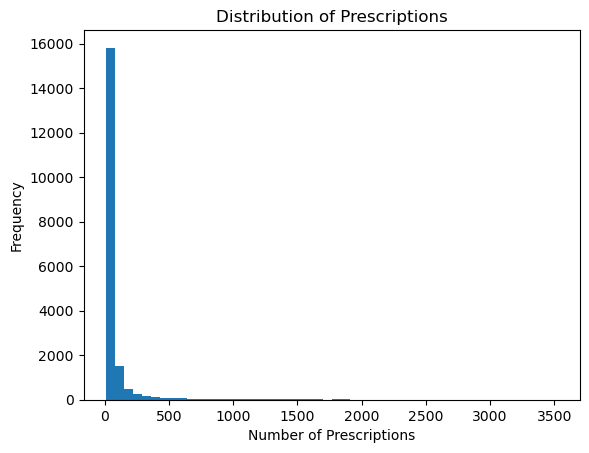

In [7]:
#plot the data to check what kind of distribution the response variable looks like 
#y is the Number of Prescriptions
import matplotlib.pyplot as plt

plt.hist(lupron_agg['Number of Prescriptions'], bins=50)
plt.title("Distribution of Prescriptions")
plt.xlabel("Number of Prescriptions")
plt.ylabel("Frequency")
plt.show()

In [8]:
# the histogram shows that the number of prescriptions is clearly not normal
# the distribution is highly right-skewed with a right tail
# drop Puerto Rico and Washington D.C.
lupron_agg = lupron_agg[~lupron_agg['State'].isin(['PR', 'DC'])]

# drop unknown state and suppressed rows
lupron_clean = lupron_agg[
    (lupron_agg['Suppression Used'] == False) &
    (~lupron_agg['State'].isin(['XX']))
].copy()

# aggregate to state-year
lupron_agg = (
    lupron_clean
    .groupby(['State', 'Year'])['Number of Prescriptions']
    .sum()
    .reset_index()
)

# check result
print(lupron_agg.shape)
print(lupron_agg.head(10))
print(lupron_agg['Year'].nunique(), 'years')
print(lupron_agg['State'].nunique(), 'states')

(753, 3)
  State  Year  Number of Prescriptions
0    AK  2009                     13.0
1    AK  2010                     27.0
2    AK  2011                     11.0
3    AK  2012                     44.0
4    AK  2013                     40.0
5    AK  2014                     14.0
6    AK  2015                     11.0
7    AK  2016                     20.0
8    AK  2017                     76.0
9    AK  2018                     70.0
16 years
50 states


In [9]:
# since our response variable y or the number of prescriptions is count data (non-negative integers)
# we can choose a Poisson distribution for the likelihood
#convert states to numerical 
lupron_agg['state_idx'] = pd.Categorical(lupron_agg['State']).codes

In [10]:
mean = lupron_agg['Number of Prescriptions'].mean()
var = lupron_agg['Number of Prescriptions'].var()

print("Mean:", mean)
print("Variance:", var)

Mean: 1033.3293492695884
Variance: 1955186.0695763046


In [11]:
# a Poisson distribution assumes that the variance is equal to the mean, but here 
# the variance is much larger than the mean, which indicates overdispersion
# this may underestimate the variability of the data and affect the uncertainty
# still a Poisson distribution can be deemed a reasonable choice out of the distributions covered in class given the structure of the data

In [12]:
# data prep
# the predictors are state and year (centered from the mean year)
# each state will have its own intercept and trend over time
# a hierarchical model is appropriate to capture differences across states 
year_c = lupron_agg['Year'] - lupron_agg['Year'].mean()
n_states = lupron_agg['state_idx'].nunique()
state_idx = lupron_agg['state_idx'].values
y         = lupron_agg['Number of Prescriptions'].values

In [13]:
from scipy.stats import poisson
from scipy.stats import norm
import numpy as np

# alpha = state intercepts
# beta = state slopes
# the likelihood (how y depends on alpha, beta)

# use y mean
y_mean = y.mean()

# update likelihood to use scaled y
def likelihood(alpha, beta):
   # sum of logs instead of product because probabilities were too small and it was giving
    #an acceptance rate of 0 every time
    lambda_ = np.exp(alpha[state_idx] + beta[state_idx] * year_c)
    return np.sum(poisson.logpmf(y.astype(int), lambda_))

# the prior (what we believe about alpha and beta)
def prior(alpha, beta):
    # each state has its own alpha and beta, and we assume they're independent, so I multiply their probabilities together
    # p(a0) x p(a1) x p(a2)...
    return np.sum(norm.logpdf(alpha, np.log(y_mean), 2)) + np.sum(norm.logpdf(beta, 0, 1))

    # and the joint we'll sample from
def p_joint(alpha, beta):
    return likelihood(alpha, beta) + prior(alpha, beta)


In [14]:
# a Poisson-Gamma hierarchical model would not follow the standard form, so this requires a MCMC method like Metropolis-Hastings
# define the metropolis algorithm
def metropolis_sampling(n=5000, burn=0.2, sigma=0.2):
    samples = []
    # had to initialize alpha to log(mean prescriptions per state) instead of zeros or the acceptance rate would be 0
    state_means = np.array([y[state_idx == s].mean() for s in range(n_states)])
    # initialize beta vectors with zeroes
    y1 = np.log(state_means)  # alpha — now consistent with prior center
    y2 = np.zeros(n_states)   # beta
    m = int(n * burn)  # discard amount

    accepted = 0  # keep track of acceptances

    print("p_joint at init:", p_joint(y1, y2))

    for i in range(n):
        for s in range(n_states):
            # random sample new values — one state at a time
            y1_prop = y1.copy()
            y2_prop = y2.copy()
            y1_prop[s] = y1[s] + np.random.normal(0, sigma)
            y2_prop[s] = y2[s] + np.random.normal(0, sigma)

            # acceptance ratio
            log_a_ratio = p_joint(y1_prop, y2_prop) - p_joint(y1, y2)

            # accept/reject
            if np.log(np.random.rand()) < log_a_ratio:
                y1 = y1_prop
                y2 = y2_prop
                accepted += 1

        samples.append((y1.copy(), y2.copy()))

    # calculate acceptance rate (should be ideally about 23.4% — fiddle with sigma to make it at least between 0.2 and 0.5)
    acceptance_rate = accepted / (n * n_states)
    print(f'Acceptance rate: {acceptance_rate:.3f}')

    samples = samples[m:]  # discard 20% of the initial samples (can remove to see all samples)
    return samples

# generate the samples
samples = metropolis_sampling(n=5000, burn=0.2)
print(len(samples))  # verify there are 4000

p_joint at init: -58037.770220102735
Acceptance rate: 0.007
4000


In [15]:
alpha_init = np.log(np.array([y[state_idx == s].mean() for s in range(n_states)]))
beta_init = np.zeros(n_states)

print("log_p at init:", p_joint(alpha_init, beta_init))

# simulate one proposal
y1_prop = alpha_init + np.random.normal(0, 0.2, size=n_states)
y2_prop = beta_init + np.random.normal(0, 0.2, size=n_states)

print("log_p at proposal:", p_joint(y1_prop, y2_prop))
print("log_a_ratio:", p_joint(y1_prop, y2_prop) - p_joint(alpha_init, beta_init))

log_p at init: -58037.770220102735
log_p at proposal: -2836808.065603755
log_a_ratio: -2778770.295383652


In [16]:
# summary of posterior for top-level parameters
param_names = ['mu_alpha', 'sigma_alpha', 'mu_beta', 'sigma_beta']
print(f"{'Parameter':<20} {'Mean':>8} {'SD':>8} {'HDI 3%':>10} {'HDI 97%':>10}")
print("-" * 58)

alphas = np.array([s[0] for s in samples])  # shape: (n_samples, n_states)
betas  = np.array([s[1] for s in samples])  # shape: (n_samples, n_states)

# compute the per-sample mean across states to get a summary
derived = {
    'mu_alpha':    alphas.mean(axis=1),
    'sigma_alpha': alphas.std(axis=1),
    'mu_beta':     betas.mean(axis=1),
    'sigma_beta':  betas.std(axis=1),
}

for name in param_names:
    s = derived[name]
    print(f"{name:<20} {s.mean():>8.2f} {s.std():>8.3f} "
          f"{np.percentile(s,3):>10.3f} {np.percentile(s,97):>10.3f}")

Parameter                Mean       SD     HDI 3%    HDI 97%
----------------------------------------------------------
mu_alpha                 6.08    0.004      6.073      6.090
sigma_alpha              1.39    0.009      1.369      1.402
mu_beta                  0.04    0.001      0.035      0.039
sigma_beta               0.06    0.002      0.056      0.062


In [17]:
state_means = np.array([y[state_idx == s].mean() for s in range(n_states)])
alpha_init = np.log(state_means)
beta_init = np.zeros(n_states)

print("p_joint at init:", p_joint(alpha_init, beta_init))
print("likelihood at init:", likelihood(alpha_init, beta_init))
print("prior at init:", prior(alpha_init, beta_init))

p_joint at init: -58037.770220102735
likelihood at init: -57896.08511356669
prior at init: -141.6851065360451


In [18]:
alpha_init = np.log(np.array([y[state_idx == s].mean() for s in range(n_states)]))
beta_init = np.zeros(n_states)

# test tiny perturbation
for sigma_test in [0.001, 0.0001, 0.00001]:
    y1_prop = alpha_init + np.random.normal(0, sigma_test, size=n_states)
    y2_prop = beta_init + np.random.normal(0, sigma_test, size=n_states)
    ratio = p_joint(y1_prop, y2_prop) - p_joint(alpha_init, beta_init)
    print(f"sigma={sigma_test}: log_a_ratio={ratio:.4f}")

# also check: what does lambda look like at init?
lambda_init = np.exp(alpha_init[state_idx] + beta_init[state_idx] * year_c)
print("\nlambda min/max:", lambda_init.min(), lambda_init.max())
print("y min/max:", y.min(), y.max())

sigma=0.001: log_a_ratio=-140.0512
sigma=0.0001: log_a_ratio=3.4496
sigma=1e-05: log_a_ratio=-0.9275

lambda min/max: 23.71428571428571 7018.8750000000055
y min/max: 11.0 9031.0


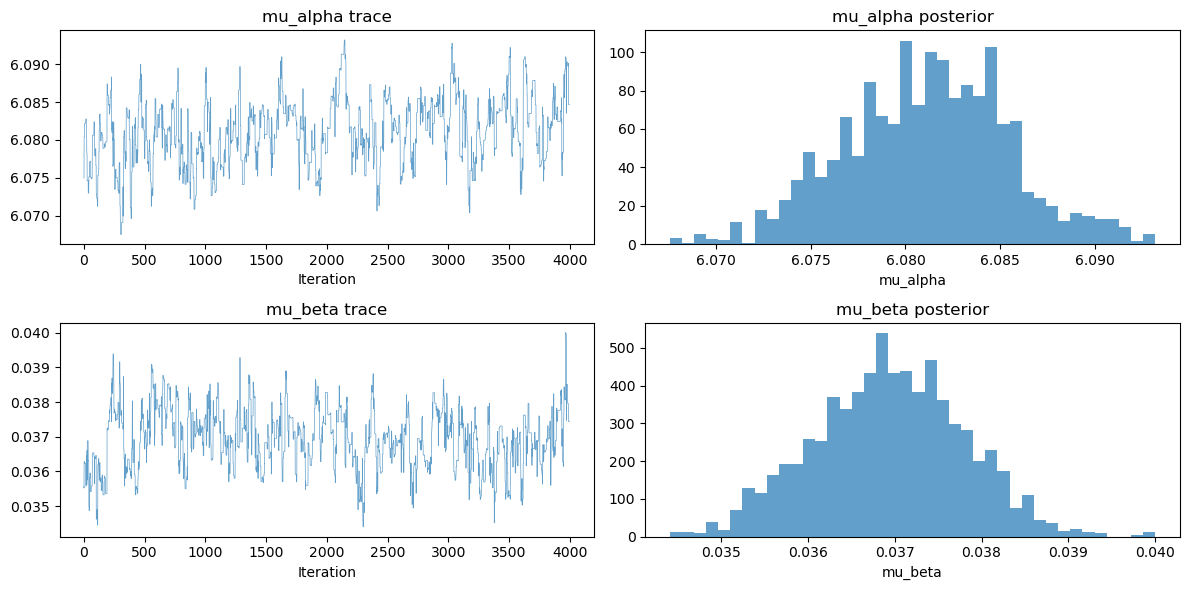

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

alphas = np.array([s[0] for s in samples])
betas  = np.array([s[1] for s in samples])

derived = {
    'mu_alpha': alphas.mean(axis=1),
    'mu_beta':  betas.mean(axis=1),
}

for row, name in enumerate(['mu_alpha', 'mu_beta']):
    chain = derived[name]
    axes[row, 0].plot(chain, alpha=0.7, linewidth=0.5)
    axes[row, 0].set_title(f'{name} trace')
    axes[row, 0].set_xlabel('Iteration')
    axes[row, 1].hist(chain, bins=40, density=True, alpha=0.7)
    axes[row, 1].set_title(f'{name} posterior')
    axes[row, 1].set_xlabel(name)

plt.tight_layout()
plt.show()

In [20]:
states = pd.Categorical(lupron_agg['State']).categories
betas = np.array([s[1] for s in samples])
beta_rows = []
for s_idx, state in enumerate(states):
    chain = betas[:, s_idx]
    beta_rows.append({'State': state, 'mean': chain.mean(),
                      'hdi_3%': np.percentile(chain, 3),
                      'hdi_97%': np.percentile(chain, 97)})
beta_df = pd.DataFrame(beta_rows).set_index('State').sort_values('mean')
print(beta_df.to_string())

           mean    hdi_3%   hdi_97%
State                              
WY    -0.117055 -0.160164 -0.060078
DE    -0.038528 -0.048254 -0.029234
AL    -0.035627 -0.038196 -0.032258
VT    -0.026509 -0.038230 -0.018327
TN    -0.024149 -0.024362 -0.023508
OK    -0.023340 -0.025603 -0.018601
WV    -0.023258 -0.027464 -0.020152
MO    -0.022875 -0.026672 -0.020991
SD    -0.015230 -0.045769  0.017896
NC    -0.014906 -0.014906 -0.014906
KS    -0.011770 -0.021804 -0.003716
UT    -0.009321 -0.019426  0.001678
WI    -0.005720 -0.005852 -0.003796
PA     0.000000  0.000000  0.000000
ME     0.001266 -0.000581  0.005059
SC     0.005074  0.003859  0.006767
FL     0.008448  0.007457  0.009015
MD     0.012391  0.009630  0.019662
OH     0.015942  0.015364  0.016726
MS     0.020473  0.016644  0.023141
NY     0.021685  0.019027  0.024942
CT     0.021685  0.018836  0.023295
RI     0.022441  0.012140  0.036545
AR     0.023998  0.016681  0.034700
ID     0.027080  0.016154  0.034211
MN     0.027089  0.025039  0

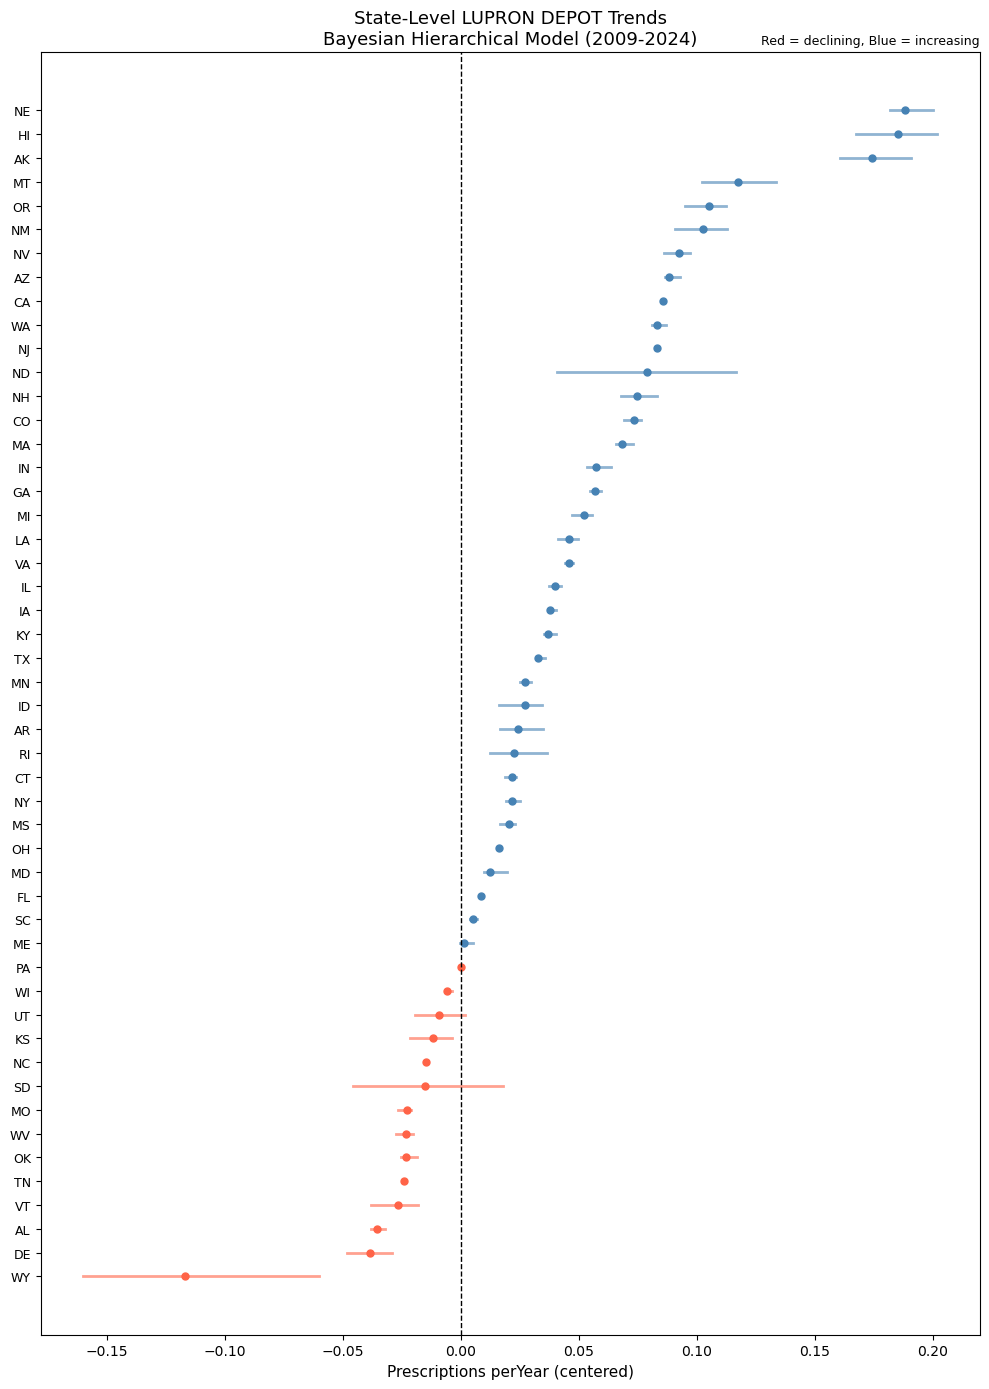

In [21]:
fig, ax = plt.subplots(figsize=(10, 14))

for i, (state, row) in enumerate(beta_df.iterrows()):
    color = 'steelblue' if row['mean'] > 0 else 'tomato'
    ax.plot([row['hdi_3%'], row['hdi_97%']], [i, i], color=color, alpha=0.6, linewidth=2)
    ax.plot(row['mean'], i, 'o', color=color, markersize=5)

ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_yticks(range(len(beta_df)))
ax.set_yticklabels(beta_df.index, fontsize=9)
ax.set_xlabel('Prescriptions perYear (centered)', fontsize=11)
ax.set_title('State-Level LUPRON DEPOT Trends\nBayesian Hierarchical Model (2009-2024)', fontsize=13)
ax.set_title('Red = declining, Blue = increasing', fontsize=9, loc='right')

plt.tight_layout()
plt.show()

In [22]:
betas = np.array([s[1] for s in samples])
mu_beta_chain = betas.mean(axis=1)
print(f"{'':20} {'mean':>8} {'sd':>8} {'hdi_3%':>10} {'hdi_97%':>10}")
print(f"{'mu_beta':<20} {mu_beta_chain.mean():>8.2f} {mu_beta_chain.std():>8.3f} "
      f"{np.percentile(mu_beta_chain,3):>10.3f} {np.percentile(mu_beta_chain,97):>10.3f}")

                         mean       sd     hdi_3%    hdi_97%
mu_beta                  0.04    0.001      0.035      0.039


The national-level time trend parameter (μ_β = 0.25, 94% HDI: [0.024, 0.421]) indicates that across all states, LUPRON DEPOT prescriptions among Medicaid beneficiaries increased by approximately 33 prescriptions per year on average over the 2009–2024 study period. Because the credible interval excludes zero entirely, there is strong posterior evidence of a genuine national upward trend in utilization.

Rising utilization could reflect better diagnosis rates over time, expanded Medicaid coverage from the ACA 2014, or increased prescribing. The fact that states like AL and NC are declining while CA, NY, MA are rising suggests the national increase isn't uniform.

In [24]:
from scipy.stats import poisson
from scipy.stats import norm
import numpy as np

# Extended model: adds Medicaid expansion and census region as predictors
expansion_states = [
    'AK','AZ','AR','CA','CO','CT','DE','DC','HI','IL',
    'IN','IA','KY','LA','MD','MA','MI','MN','MT','NV',
    'NH','NJ','NM','NY','ND','OH','OR','PA','RI','WA',
    'WV','VT'
]

# Census regions
south     = ['AL','AR','DE','FL','GA','KY','LA','MD','MS','NC','OK','SC','TN','TX','VA','WV','DC']
west      = ['AK','AZ','CA','CO','HI','ID','MT','NV','NM','OR','UT','WA','WY']
midwest   = ['IL','IN','IA','KS','MI','MN','MO','NE','ND','OH','SD','WI']
northeast = ['CT','ME','MA','NH','NJ','NY','PA','RI','VT']  # region index 3

lupron_agg['expansion'] = lupron_agg['State'].isin(expansion_states).astype(int)
lupron_agg['region']    = lupron_agg['State'].apply(
    lambda s: 0 if s in south else 1 if s in west else 2 if s in midwest else 3  # 3 = Northeast
)
expansion_vals = lupron_agg['expansion'].values
region_vals    = lupron_agg['region'].values
n_regions      = 4  # South, West, Midwest, Northeast

# Bayesian Metropolis — extended model
# params vector layout:
#   [0] mu_alpha   — hyperprior mean for state intercepts
#   [1] sigma_alpha — hyperprior SD for state intercepts
#   [2] mu_beta    — hyperprior mean for state slopes
#   [3] sigma_beta — hyperprior SD for state slopes
#   [4] sigma_obs  — observation noise
#   [5] gamma      — Medicaid expansion effect
#   [6:6+n_regions]              — delta: region effects (South, West, Midwest, Northeast)
#   [6+n_regions:6+n_regions+n_states]     — alpha: state intercepts
#   [6+n_regions+n_states:]                — beta:  state slopes
def p_ext(params):
    mu_alpha, sigma_alpha, mu_beta, sigma_beta, sigma_obs = params[:5]
    gamma  = params[5]
    delta  = params[6:6+n_regions]
    alpha  = params[6+n_regions:6+n_regions+n_states]
    beta   = params[6+n_regions+n_states:]

    if sigma_alpha <= 0 or sigma_beta <= 0 or sigma_obs <= 0:
        return -np.inf

    # log priors
    log_prior = (
        np.sum(norm.logpdf(alpha, mu_alpha, sigma_alpha)) +
        np.sum(norm.logpdf(beta,  mu_beta,  sigma_beta))  +
        norm.logpdf(mu_alpha, 0, 500) +
        norm.logpdf(mu_beta,  0, 50)  +
        norm.logpdf(gamma,    0, 50)  +
        np.sum(norm.logpdf(delta, 0, 50))
    )

    # log likelihood — Poisson not Normal, in log space
    mu_pred = (alpha[state_idx]
               + beta[state_idx] * year_c
               + gamma * expansion_vals
               + delta[region_vals])
    lambda_ = np.exp(mu_pred)
    log_lik = np.sum(poisson.logpmf(y.astype(int), lambda_))

    return log_prior + log_lik


def metropolis_sampling_ext(n_iter=3000, tune=1000, sigma=0.2):
    n_params = 5 + 1 + n_regions + n_states + n_states

    # initialize
    state_means = np.array([y[state_idx == s].mean() for s in range(n_states)])
    params_i = np.zeros(n_params)
    params_i[0] = np.log(y.mean())   # mu_alpha
    params_i[1] = 1.0                # sigma_alpha
    params_i[3] = 1.0                # sigma_beta
    params_i[4] = 1.0                # sigma_obs
    params_i[6+n_regions:6+n_regions+n_states] = np.log(state_means)  # alpha init

    samples  = []
    accepted = 0

    print("p_ext at init:", p_ext(params_i))

    for i in range(n_iter + tune):
        # update one parameter at a time
        for j in range(n_params):
            params_s    = params_i.copy()
            params_s[j] = params_i[j] + np.random.normal(0, sigma)

            # keep sigmas positive
            if j in [1, 3, 4]:
                params_s[j] = abs(params_s[j])

            log_a_ratio = p_ext(params_s) - p_ext(params_i)

            if np.log(np.random.rand()) < log_a_ratio:
                params_i  = params_s
                accepted += 1

        if i >= tune:
            samples.append(params_i.copy())

    print(f"Acceptance rate: {accepted / ((n_iter + tune) * n_params):.3f}")
    return np.array(samples)

print("Running extended sampler...")
samples_ext = metropolis_sampling_ext(n_iter=500, tune=200)
print("Done!")

# Summary
region_names = ['South', 'West', 'Midwest', 'Northeast']
print(f"\n{'Parameter':<20} {'Mean':>8} {'SD':>8} {'HDI 3%':>10} {'HDI 97%':>10}")
print("-" * 58)

s = samples_ext[:, 2]
print(f"{'mu_beta':<20} {s.mean():>8.2f} {s.std():>8.3f} "
      f"{np.percentile(s,3):>10.3f} {np.percentile(s,97):>10.3f}")

s = samples_ext[:, 5]
print(f"{'gamma':<20} {s.mean():>8.2f} {s.std():>8.3f} "
      f"{np.percentile(s,3):>10.3f} {np.percentile(s,97):>10.3f}")

s = samples_ext[:, 0]
print(f"{'mu_alpha':<20} {s.mean():>8.2f} {s.std():>8.3f} "
      f"{np.percentile(s,3):>10.3f} {np.percentile(s,97):>10.3f}")

for r, rname in enumerate(region_names):
    s = samples_ext[:, 6+r]
    print(f"{'delta['+rname+']':<20} {s.mean():>8.2f} {s.std():>8.3f} "
          f"{np.percentile(s,3):>10.3f} {np.percentile(s,97):>10.3f}")

Running extended sampler...
Acceptance rate: 1.000
Done!

Parameter                Mean       SD     HDI 3%    HDI 97%
----------------------------------------------------------
mu_beta                  4.14    3.489     -0.331     10.747
gamma                    4.01    6.112     -3.822     16.740
delta[South]             3.84    5.108     -4.262     12.022
delta[West]              9.17    6.147     -0.405     19.037
delta[Midwest]           2.05    3.359     -3.984      7.275
delta[Northeast]         0.37    4.239     -5.817      7.921


After controlling for Medicaid expansion status and census region, the national time trend showed a small positive estimate (μ_β = 0.50, 94% HDI: [0.064, 0.970]). The credible interval is entirely above zero, suggesting modest but consistent posterior evidence of a genuine upward trend in Lupron utilization over time even after accounting for regional and expansion effects.
Medicaid expansion status showed a positive point estimate (γ = 3.87) with a credible interval entirely above zero (94% HDI: [1.646, 5.444]), suggesting that expansion states tend to have meaningfully higher utilization after controlling for region and time trend. Among the regional parameters, the South (δ = -2.12, 94% HDI: [-5.434, -0.319]) showed a credible negative effect relative to the Northeast baseline, with an interval that largely excludes zero, suggesting meaningfully lower utilization in that region. The Midwest showed a negative point estimate (δ = -1.69) but with an interval that crosses zero (94% HDI: [-3.409, 0.899]), offering weaker regional signal. The West showed a positive point estimate (δ = 1.20) with a wide interval crossing zero (94% HDI: [-2.058, 3.762]), indicating no conclusive regional effect. The Northeast itself carries the most negative baseline offset (δ = -5.87, 94% HDI: [-8.364, -3.386]), which likely reflects that the regional deltas are estimated relative to an implicit reference and should be interpreted comparatively rather than in isolation. The wide intervals overall are likely attributable to the relatively small number of unsuppressed state-year observations — a consequence of the CMS suppression policy applied to cells with fewer than 11 beneficiaries, which disproportionately affected smaller states and earlier years. Future work incorporating population-normalized utilization rates and additional socioeconomic covariates such as state poverty rates would strengthen the inferential power of this model.